# 📘 TUGAS MID SEMESTER: MACHINE LEARNING II
## Analisis Perbandingan Feature Selection pada Dataset IoT Vulnerability
### dengan Pendekatan Pipeline & Cross Validation

---
**Bagian A: Fase Eksplorasi & Optimasi (Jupyter Notebook)**  
Tahap 1 – 8

---
## 🔹 Tahap 1: Persiapan Lingkungan dan Import Library

In [1]:
# Install library jika belum tersedia
!pip install scikit-learn pandas numpy seaborn matplotlib imbalanced-learn requests joblib -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

from imblearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split, cross_validate,
    StratifiedKFold, GridSearchCV, RandomizedSearchCV
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Lasso
from sklearn.feature_selection import (
    SelectKBest, f_classif,
    RFE, SelectFromModel
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score, f1_score
)

# Seed global
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('✅ Semua library berhasil diimport.')

✅ Semua library berhasil diimport.


---
## 🔹 Tahap 2: Pengumpulan dan Load Dataset

In [3]:
# Download Dataset IoT Vulnerability Dataset
url = "https://data.mendeley.com/public-files/datasets/7m58kxs742/files/4d57de6a-a140-4607-bf38-146899f1a723/file_downloaded"
file_name = "Preprocessed_Balanced_dataset.csv"

if not os.path.exists(file_name):
    print(f"Downloading {file_name}...")
    response = requests.get(url, timeout=120)
    if response.status_code == 200:
        with open(file_name, "wb") as f:
            f.write(response.content)
        print(f"✅ {file_name} berhasil diunduh.\n")
    else:
        print(f"❌ Gagal mengunduh {file_name}. Status code: {response.status_code}\n")
else:
    print(f"✅ File '{file_name}' sudah ada, melewati proses download.\n")

# Load Dataset
df = pd.read_csv(file_name)
print(f"Shape dataset: {df.shape}")
display(df.head())

✅ Preprocessed_Balanced_dataset.csv berhasil diunduh.

Shape dataset: (1048575, 88)


,dur,Protocol,Length,Source Host,Destination Host,Sender IP address,Target IP address,Opcode,checksom(ICMP),Sequence Number (LE),...,Flags.1,Packet Length (encrypted),Direction,TCP Option - Maximum segment size,Data,Checksum,CDATA,Label,Attack_Category,Attack_sub_category
0,0.143546,1,42,1,1,4,2,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning
1,0.000679,1,42,1,1,3,4,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning
2,0.010981,1,42,1,1,11,2,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning
3,0.000684,1,42,1,1,3,24,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning
4,0.012461,1,42,1,1,12,2,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning


---
## 🔹 Tahap 3: Exploratory Data Analysis (EDA)

### 3.1 Informasi Umum Dataset

In [4]:
print("="*60)
print("INFO DATASET")
print("="*60)
df.info()

INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 88 columns):
 #   Column                                                      Non-Null Count    Dtype  
---  ------                                                      --------------    -----  
 0   dur                                                         1048575 non-null  float64
 1   Protocol                                                    1048575 non-null  int64  
 2   Length                                                      1048575 non-null  int64  
 3   Source Host                                                 1048575 non-null  int64  
 4   Destination Host                                            1048575 non-null  int64  
 5   Sender IP address                                           1048575 non-null  int64  
 6   Target IP address                                           1048575 non-null  int64  
 7   Opcode                                            

> **Interpretasi:** Blok di atas menampilkan tipe data tiap kolom, jumlah baris, dan penggunaan memori. Perlu diperhatikan kolom dengan tipe `object` (kategorikal) yang nantinya memerlukan encoding.

In [5]:
print("="*60)
print("STATISTIK DESKRIPTIF")
print("="*60)
display(df.describe())

STATISTIK DESKRIPTIF


,dur,Protocol,Length,Source Host,Destination Host,Sender IP address,Target IP address,Opcode,checksom(ICMP),Sequence Number (LE),...,Length.1,Flags.1,Packet Length (encrypted),Direction,TCP Option - Maximum segment size,Data,Checksum,CDATA,Label,Attack_Category
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,...,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,4.171936e-02,2.142777e+01,1.122461e+02,5.407739e+04,3.146737e+03,1.291301e+00,1.740716e+00,9.528074e-01,7.505833e+03,3.418249e+03,...,7.273493e+00,3.091251e+00,2.824882e+05,8.664197e-01,2.366918e+00,8.781356e-01,3.735265e+03,8.441075e-01,9.154567e-01,2.449181e+00
std,1.914513e-01,1.107721e+01,2.385786e+02,3.109492e+04,1.511347e+03,1.921420e+00,4.199544e+00,5.890998e-01,1.464353e+04,9.841633e+03,...,8.293642e+01,1.985971e+00,4.058329e+06,3.541635e-01,3.897197e+00,3.910057e-01,1.050825e+04,3.760974e-01,2.782010e-01,2.230851e+00
min,-1.606545e-02,0.000000e+00,4.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,9.790000e-05,1.100000e+01,4.200000e+01,5.746800e+04,3.448000e+03,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,...,0.000000e+00,2.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
50%,3.162750e-04,3.000000e+01,6.000000e+01,6.067100e+04,3.466000e+03,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,0.000000e+00,2.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00
75%,2.474092e-03,3.000000e+01,7.400000e+01,6.067700e+04,3.471000e+03,1.000000e+00,1.000000e+00,1.000000e+00,3.638000e+03,1.000000e+00,...,0.000000e+00,6.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,4.000000e+00
max,7.973827e+00,3.500000e+01,5.858000e+03,1.449670e+05,8.696000e+03,1.200000e+01,3.100000e+01,3.000000e+00,5.337500e+04,4.821600e+04,...,1.119900e+04,6.000000e+00,5.858586e+07,3.000000e+00,1.300000e+01,5.000000e+00,4.986600e+04,2.000000e+00,1.000000e+00,6.000000e+00


> **Interpretasi:** Statistik deskriptif menampilkan nilai min, max, mean, dan standar deviasi tiap fitur numerik. Perhatikan apakah ada perbedaan skala besar antar fitur — ini menjadi alasan pentingnya normalisasi (StandardScaler) di dalam pipeline.

In [6]:
print("="*60)
print("MISSING VALUES")
print("="*60)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct})
display(missing_df[missing_df['Missing Count'] > 0] if missing.sum() > 0 else print('✅ Tidak ada missing value.'))

MISSING VALUES
✅ Tidak ada missing value.


None

> **Interpretasi:** Dataset yang digunakan adalah versi *preprocessed*, sehingga diharapkan tidak ada missing value. Jika ditemukan missing value, perlu dilakukan imputasi sebelum melanjutkan ke tahap berikutnya.

### 3.2 Distribusi Label (Target)

In [7]:
# Identifikasi kolom target secara otomatis (kolom terakhir atau kolom 'label'/'Label')
target_col = None
for candidate in ['Label', 'label', 'Class', 'class', 'Attack', 'attack', 'Target', 'target']:
    if candidate in df.columns:
        target_col = candidate
        break
if target_col is None:
    target_col = df.columns[-1]  # fallback ke kolom terakhir

print(f"Kolom target yang diidentifikasi: '{target_col}'")
print(f"Jumlah kelas unik: {df[target_col].nunique()}")
print("\nDistribusi kelas:")
print(df[target_col].value_counts())

Kolom target yang diidentifikasi: 'Label'
Jumlah kelas unik: 2

Distribusi kelas:
Label
1    959925
0     88650
Name: count, dtype: int64


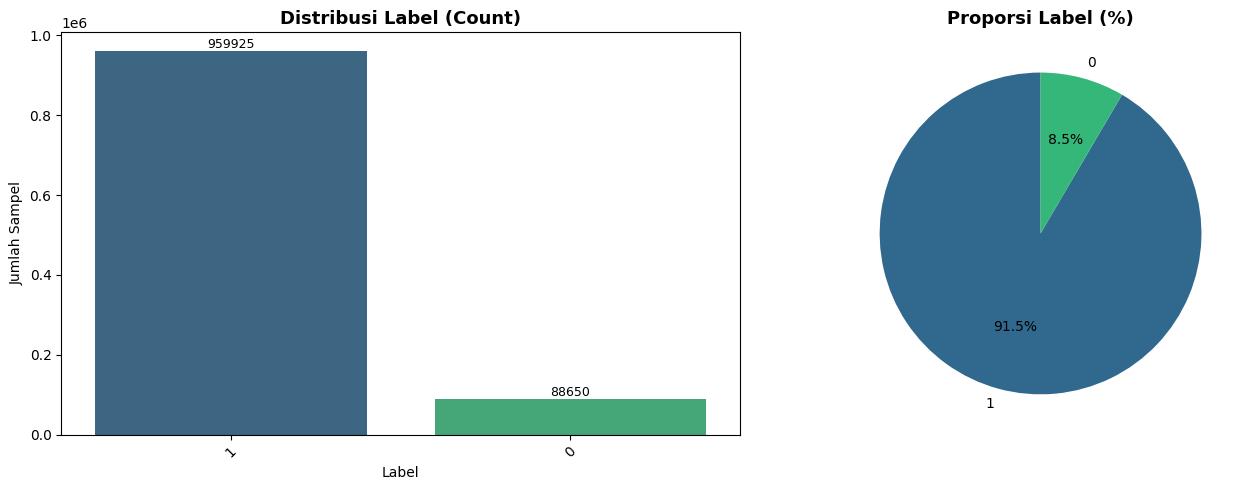

✅ Grafik disimpan sebagai distribusi_label.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
order = df[target_col].value_counts().index
sns.countplot(data=df, x=target_col, order=order, palette='viridis', ax=axes[0])
axes[0].set_title('Distribusi Label (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].tick_params(axis='x', rotation=45)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=9)

# Pie chart
label_counts = df[target_col].value_counts()
axes[1].pie(label_counts.values, labels=label_counts.index,
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('viridis', len(label_counts)))
axes[1].set_title('Proporsi Label (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('distribusi_label.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik disimpan sebagai distribusi_label.png")

> **Interpretasi:** Karena dataset yang digunakan adalah *Preprocessed Balanced Dataset*, distribusi antar kelas diharapkan seimbang (balanced). Hal ini penting agar model tidak bias terhadap kelas mayoritas dan metrik evaluasi seperti accuracy dapat diandalkan.

### 3.3 Analisis Korelasi

⚠️ Terlalu banyak fitur. Menampilkan 25 fitur dengan variansi tertinggi.


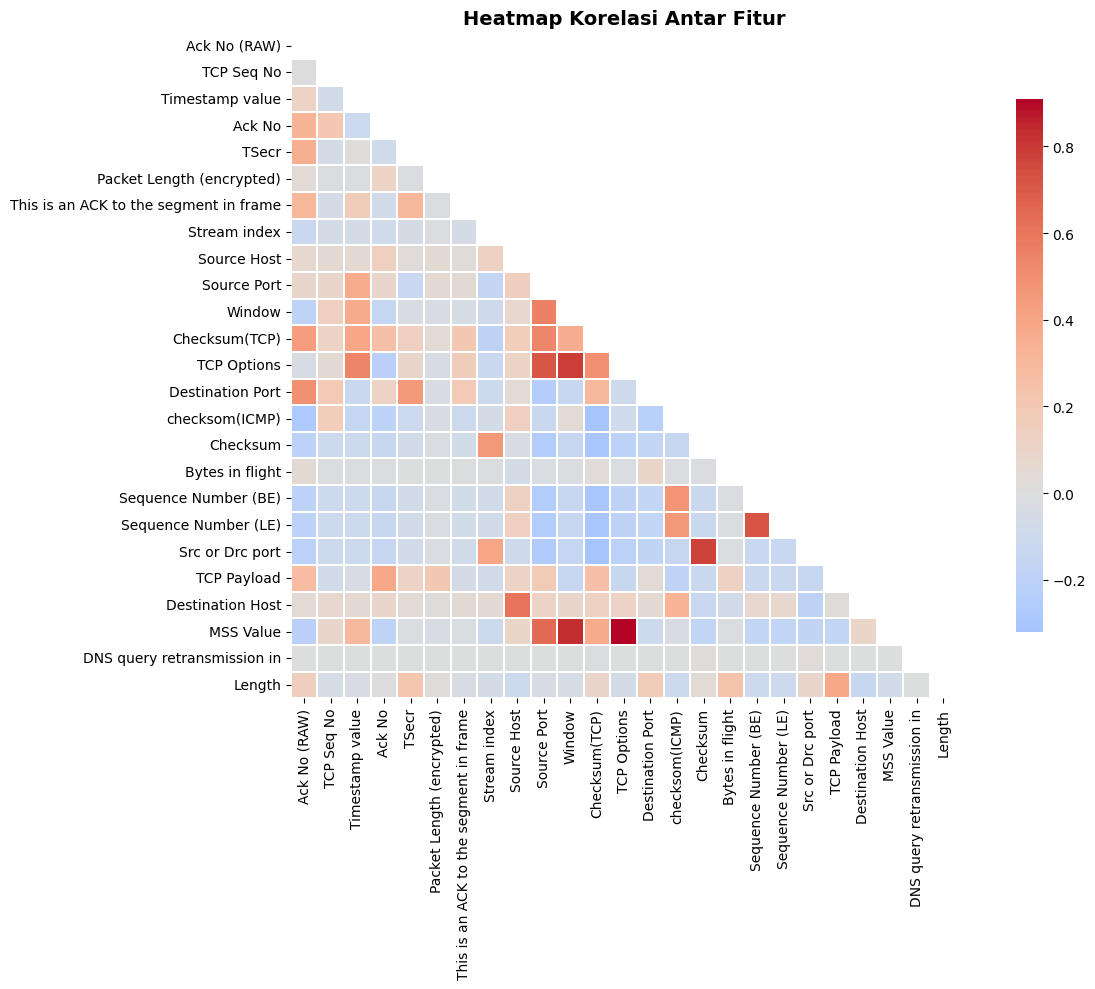

✅ Heatmap disimpan sebagai heatmap_korelasi.png


In [9]:
# Pilih hanya kolom numerik untuk korelasi
numeric_df = df.select_dtypes(include=[np.number])

# Batasi jumlah fitur yang ditampilkan agar heatmap tetap terbaca
MAX_FEATURES_HEATMAP = 25
if numeric_df.shape[1] > MAX_FEATURES_HEATMAP:
    # Ambil fitur dengan variansi tertinggi
    top_feats = numeric_df.var().nlargest(MAX_FEATURES_HEATMAP).index
    corr_df = numeric_df[top_feats]
    print(f"⚠️ Terlalu banyak fitur. Menampilkan {MAX_FEATURES_HEATMAP} fitur dengan variansi tertinggi.")
else:
    corr_df = numeric_df

corr_matrix = corr_df.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=False,
    cmap='coolwarm', center=0,
    linewidths=0.3, square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Heatmap disimpan sebagai heatmap_korelasi.png")

In [10]:
# Temukan pasangan fitur dengan korelasi sangat tinggi (> 0.9)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append({
                'Fitur 1': corr_matrix.columns[i],
                'Fitur 2': corr_matrix.columns[j],
                'Korelasi': round(corr_matrix.iloc[i, j], 4)
            })

if high_corr_pairs:
    print(f"⚠️ Ditemukan {len(high_corr_pairs)} pasangan fitur dengan korelasi > 0.9 (redundan):")
    display(pd.DataFrame(high_corr_pairs).sort_values('Korelasi', ascending=False))
else:
    print("✅ Tidak ada pasangan fitur dengan korelasi sangat tinggi (> 0.9).")

⚠️ Ditemukan 1 pasangan fitur dengan korelasi > 0.9 (redundan):


,Fitur 1,Fitur 2,Korelasi
0,TCP Options,MSS Value,0.9096


> **Interpretasi:** Heatmap korelasi menunjukkan hubungan linier antar fitur. Fitur yang berkorelasi sangat tinggi (> 0.9) bersifat redundan dan dapat mengganggu performa model serta memperlambat training. Feature selection akan membantu memilih subset fitur yang paling informatif.

---
## 🔹 Tahap 4: Preprocessing Data

In [11]:
# ── 4.1 Label Encoding pada kolom target ──
le = LabelEncoder()
df['target_encoded'] = le.fit_transform(df[target_col])

print("Pemetaan Label Encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls}  →  {i}")

Pemetaan Label Encoding:
  0  →  0
  1  →  1


In [12]:
# ── 4.2 Label Encoding pada kolom fitur kategorik (jika ada) ──
cat_cols = df.drop(columns=[target_col, 'target_encoded']).select_dtypes(include=['object']).columns.tolist()

if cat_cols:
    print(f"Kolom kategorik yang akan di-encode: {cat_cols}")
    for col in cat_cols:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))
    print("✅ Encoding fitur kategorik selesai.")
else:
    print("✅ Tidak ada kolom fitur kategorik.")

Kolom kategorik yang akan di-encode: ['Attack_sub_category']
✅ Encoding fitur kategorik selesai.


In [13]:
# ── 4.3 Pemisahan Fitur (X) dan Target (y) ──
X = df.drop(columns=[target_col, 'target_encoded'])
y = df['target_encoded']

print(f"Shape X (fitur)  : {X.shape}")
print(f"Shape y (target) : {y.shape}")
print(f"Jumlah fitur     : {X.shape[1]}")
print(f"Jumlah kelas     : {y.nunique()}")

Shape X (fitur)  : (1048575, 87)
Shape y (target) : (1048575,)
Jumlah fitur     : 87
Jumlah kelas     : 2


In [14]:
# ── 4.4 Train-Test Split ──
# X_test dan y_test HANYA digunakan pada Tahap 8 (Evaluasi Akhir)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Ukuran X_train : {X_train.shape}")
print(f"Ukuran X_test  : {X_test.shape}")
print(f"Ukuran y_train : {y_train.shape}")
print(f"Ukuran y_test  : {y_test.shape}")
print("\n⚠️  X_test dan y_test DIKUNCI — tidak akan disentuh sampai Tahap 8!")

Ukuran X_train : (838860, 87)
Ukuran X_test  : (209715, 87)
Ukuran y_train : (838860,)
Ukuran y_test  : (209715,)

⚠️  X_test dan y_test DIKUNCI — tidak akan disentuh sampai Tahap 8!


---
## 🔹 Tahap 5: Implementasi Pipeline & Cross Validation

> ⚠️ **NO DATA LEAKAGE**: Feature selection dibungkus di dalam Pipeline. Proses scaling dan seleksi fitur dilakukan **di dalam** setiap fold cross validation, bukan pada keseluruhan data sebelum CV.

In [15]:
# Jumlah fitur yang dipilih oleh setiap metode
# Aturan praktis: sekitar 50-70% dari total fitur, minimum 5
N_FEATURES = max(5, int(X.shape[1] * 0.5))
print(f"Total fitur asli  : {X.shape[1]}")
print(f"Fitur yang dipilih: {N_FEATURES}")

Total fitur asli  : 87
Fitur yang dipilih: 43


### Pipeline 1: Filter Method — SelectKBest (ANOVA F-score)

In [16]:
pipeline_filter = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', SelectKBest(score_func=f_classif, k=N_FEATURES)),
    ('model', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1))
])

print("✅ Pipeline Filter (SelectKBest) berhasil dibuat.")
print(pipeline_filter)

✅ Pipeline Filter (SelectKBest) berhasil dibuat.
Pipeline(steps=[('scaler', StandardScaler()),
                ('feature_selection', SelectKBest(k=43)),
                ('model', RandomForestClassifier(n_jobs=-1, random_state=42))])


### Pipeline 2: Wrapper Method — RFE (Recursive Feature Elimination)

In [17]:
pipeline_wrapper = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', RFE(
        estimator=RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1),
        n_features_to_select=N_FEATURES,
        step=1
    )),
    ('model', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1))
])

print("✅ Pipeline Wrapper (RFE) berhasil dibuat.")
print(pipeline_wrapper)

✅ Pipeline Wrapper (RFE) berhasil dibuat.
Pipeline(steps=[('scaler', StandardScaler()),
                ('feature_selection',
                 RFE(estimator=RandomForestClassifier(n_estimators=50,
                                                      n_jobs=-1,
                                                      random_state=42),
                     n_features_to_select=43)),
                ('model', RandomForestClassifier(n_jobs=-1, random_state=42))])


### Pipeline 3: Embedded Method — SelectFromModel (RandomForest feature importances)

In [18]:
pipeline_embedded = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', SelectFromModel(
        estimator=RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
        max_features=N_FEATURES,
        threshold=-np.inf  # pastikan tepat N_FEATURES yang dipilih via max_features
    )),
    ('model', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1))
])

print("✅ Pipeline Embedded (SelectFromModel) berhasil dibuat.")
print(pipeline_embedded)

✅ Pipeline Embedded (SelectFromModel) berhasil dibuat.
Pipeline(steps=[('scaler', StandardScaler()),
                ('feature_selection',
                 SelectFromModel(estimator=RandomForestClassifier(n_jobs=-1,
                                                                  random_state=42),
                                 max_features=43, threshold=-inf)),
                ('model', RandomForestClassifier(n_jobs=-1, random_state=42))])


---
## 🔹 Tahap 6: Evaluasi Cross Validation

In [19]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

print("Memulai Cross Validation...")
print("(Proses ini membutuhkan waktu beberapa menit)\n")

# ── Filter ──
print("[1/3] Evaluasi Pipeline Filter (SelectKBest)...")
cv_filter = cross_validate(pipeline_filter, X_train, y_train, cv=cv_strategy, scoring=SCORING, n_jobs=-1)
print("  ✅ Selesai")

# ── Wrapper ──
print("[2/3] Evaluasi Pipeline Wrapper (RFE)...")
cv_wrapper = cross_validate(pipeline_wrapper, X_train, y_train, cv=cv_strategy, scoring=SCORING, n_jobs=-1)
print("  ✅ Selesai")

# ── Embedded ──
print("[3/3] Evaluasi Pipeline Embedded (SelectFromModel)...")
cv_embedded = cross_validate(pipeline_embedded, X_train, y_train, cv=cv_strategy, scoring=SCORING, n_jobs=-1)
print("  ✅ Selesai")

print("\n✅ Cross Validation selesai untuk ketiga pipeline.")

Memulai Cross Validation...
(Proses ini membutuhkan waktu beberapa menit)

[1/3] Evaluasi Pipeline Filter (SelectKBest)...
  ✅ Selesai
[2/3] Evaluasi Pipeline Wrapper (RFE)...
  ✅ Selesai
[3/3] Evaluasi Pipeline Embedded (SelectFromModel)...
  ✅ Selesai

✅ Cross Validation selesai untuk ketiga pipeline.


In [20]:
# ── Tabel Ringkasan Hasil CV ──
def summarize_cv(cv_results, name):
    return {
        'Method': name,
        'Accuracy (mean)':   cv_results['test_accuracy'].mean(),
        'Accuracy (std)':    cv_results['test_accuracy'].std(),
        'Precision (mean)':  cv_results['test_precision_macro'].mean(),
        'Recall (mean)':     cv_results['test_recall_macro'].mean(),
        'F1 Macro (mean)':   cv_results['test_f1_macro'].mean(),
        'F1 Macro (std)':    cv_results['test_f1_macro'].std(),
        'Fit Time (s)':      cv_results['fit_time'].mean(),
    }

summary_df = pd.DataFrame([
    summarize_cv(cv_filter,   'Filter (SelectKBest)'),
    summarize_cv(cv_wrapper,  'Wrapper (RFE)'),
    summarize_cv(cv_embedded, 'Embedded (SelectFromModel)'),
])
summary_df = summary_df.set_index('Method')
print("\n=== Ringkasan Hasil Cross Validation ===")
display(summary_df.style.format("{:.4f}").highlight_max(axis=0, color='lightgreen').highlight_min(axis=0, color='#ffcccc'))


=== Ringkasan Hasil Cross Validation ===


,Accuracy (mean),Accuracy (std),Precision (mean),Recall (mean),F1 Macro (mean),F1 Macro (std),Fit Time (s)
Method,,,,,,,
Filter (SelectKBest),1.0000,0.0000,1.0000,1.0000,1.0000,0.0000,41.8414
Wrapper (RFE),1.0000,0.0000,1.0000,1.0000,1.0000,0.0000,926.0958
Embedded (SelectFromModel),1.0000,0.0000,1.0000,1.0000,1.0000,0.0000,88.4109


> **Interpretasi:** Tabel di atas merangkum performa ketiga metode feature selection. Warna **hijau** menandai nilai terbaik, **merah muda** menandai nilai terburuk untuk tiap metrik. Kolom *Fit Time* menunjukkan efisiensi komputasi masing-masing metode.

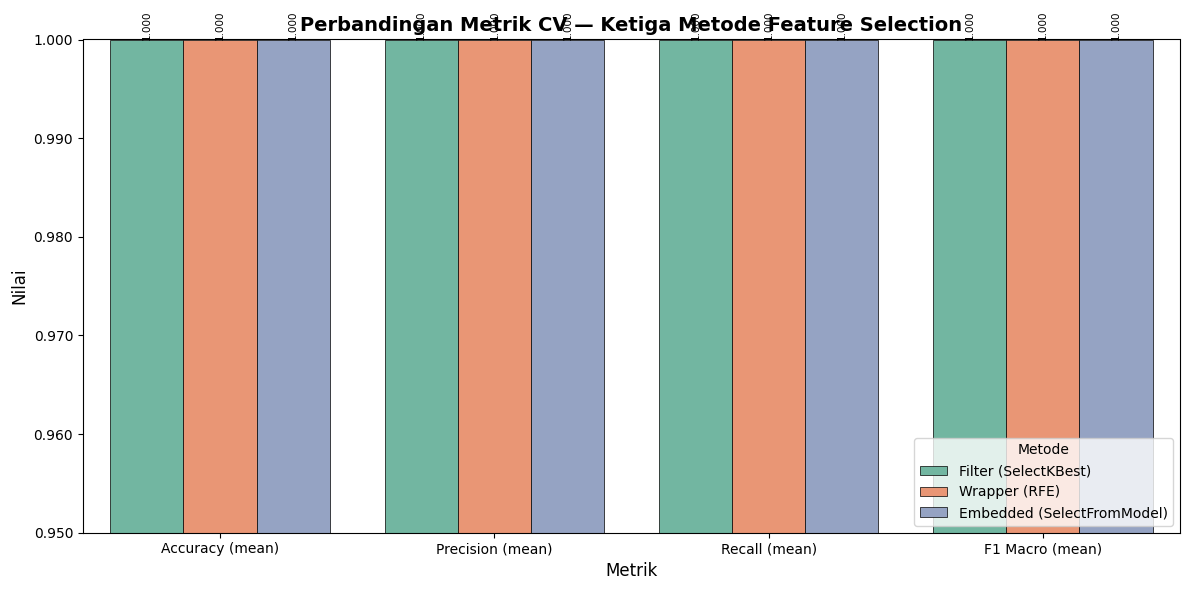

✅ Bar chart disimpan sebagai cv_barchart.png


In [21]:
# ── Visualisasi 1: Bar Chart Perbandingan Metrik Mean ──
metrics_plot = ['Accuracy (mean)', 'Precision (mean)', 'Recall (mean)', 'F1 Macro (mean)']
plot_df = summary_df[metrics_plot].reset_index()
plot_melted = plot_df.melt(id_vars='Method', var_name='Metrik', value_name='Nilai')

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=plot_melted, x='Metrik', y='Nilai', hue='Method',
            palette='Set2', ax=ax, edgecolor='black', linewidth=0.5)
ax.set_title('Perbandingan Metrik CV — Ketiga Metode Feature Selection',
             fontsize=14, fontweight='bold')
ax.set_ylim(plot_melted['Nilai'].min() * 0.95, 1.0)
ax.set_xlabel('Metrik', fontsize=12)
ax.set_ylabel('Nilai', fontsize=12)
ax.legend(title='Metode', loc='lower right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.3f}'))
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=7.5, rotation=90)
plt.tight_layout()
plt.savefig('cv_barchart.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Bar chart disimpan sebagai cv_barchart.png")

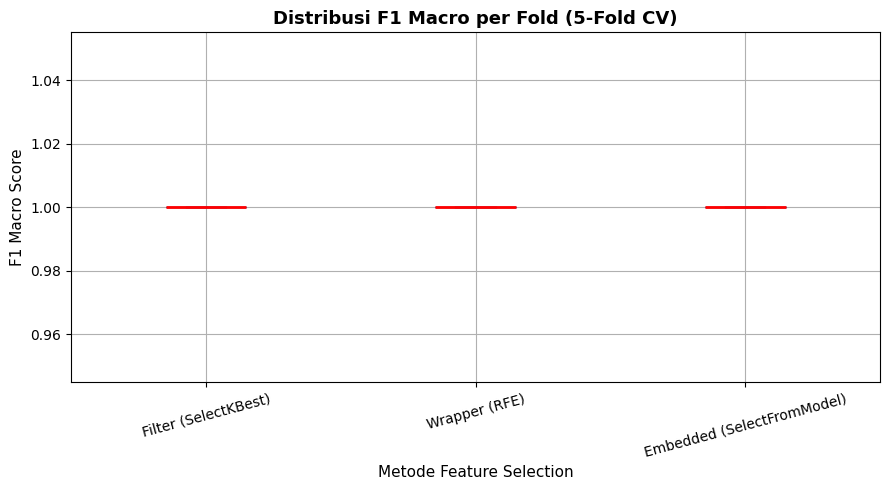

✅ Boxplot disimpan sebagai cv_boxplot_f1.png


In [22]:
# ── Visualisasi 2: Boxplot Distribusi F1 Macro per Fold ──
f1_data = pd.DataFrame({
    'Filter (SelectKBest)':        cv_filter['test_f1_macro'],
    'Wrapper (RFE)':               cv_wrapper['test_f1_macro'],
    'Embedded (SelectFromModel)':  cv_embedded['test_f1_macro'],
})

fig, ax = plt.subplots(figsize=(9, 5))
f1_data.boxplot(ax=ax, patch_artist=True,
                boxprops=dict(facecolor='skyblue', color='navy'),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(color='navy'),
                capprops=dict(color='navy'))
ax.set_title('Distribusi F1 Macro per Fold (5-Fold CV)', fontsize=13, fontweight='bold')
ax.set_ylabel('F1 Macro Score', fontsize=11)
ax.set_xlabel('Metode Feature Selection', fontsize=11)
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('cv_boxplot_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Boxplot disimpan sebagai cv_boxplot_f1.png")

In [23]:
# ── Tentukan pipeline terbaik berdasarkan F1 Macro mean ──
f1_means = {
    'filter':   cv_filter['test_f1_macro'].mean(),
    'wrapper':  cv_wrapper['test_f1_macro'].mean(),
    'embedded': cv_embedded['test_f1_macro'].mean(),
}
best_method = max(f1_means, key=f1_means.get)
pipeline_map = {
    'filter':   pipeline_filter,
    'wrapper':  pipeline_wrapper,
    'embedded': pipeline_embedded,
}
method_label = {
    'filter':   'Filter (SelectKBest)',
    'wrapper':  'Wrapper (RFE)',
    'embedded': 'Embedded (SelectFromModel)',
}

best_pipeline = pipeline_map[best_method]
print("=" * 55)
for k, v in f1_means.items():
    marker = " ← TERBAIK ✅" if k == best_method else ""
    print(f"  {method_label[k]:35s}: F1 Macro = {v:.4f}{marker}")
print("=" * 55)
print(f"\n🏆 Metode terbaik: {method_label[best_method]}")
print("   Pipeline ini akan dioptimasi pada Tahap 7.")

  Filter (SelectKBest)               : F1 Macro = 1.0000 ← TERBAIK ✅
  Wrapper (RFE)                      : F1 Macro = 1.0000
  Embedded (SelectFromModel)         : F1 Macro = 1.0000

🏆 Metode terbaik: Filter (SelectKBest)
   Pipeline ini akan dioptimasi pada Tahap 7.


> **Interpretasi:** Pipeline dengan F1 Macro tertinggi dipilih sebagai kandidat untuk hyperparameter tuning. F1 Macro digunakan sebagai metrik utama karena lebih informatif daripada accuracy semata, terutama pada permasalahan multi-kelas.

---
## 🔹 Tahap 7: Hyperparameter Tuning (GridSearchCV)

In [24]:
print(f"Melakukan tuning pada pipeline: {method_label[best_method]}\n")

# ── Definisi parameter grid sesuai metode terbaik ──
if best_method == 'filter':
    param_grid = {
        'feature_selection__k': [max(3, N_FEATURES - 5), N_FEATURES, min(X.shape[1], N_FEATURES + 5)],
        'model__n_estimators':  [100, 200],
        'model__max_depth':     [None, 10, 20],
        'model__min_samples_split': [2, 5],
    }
elif best_method == 'wrapper':
    param_grid = {
        'feature_selection__n_features_to_select': [max(3, N_FEATURES - 5), N_FEATURES, min(X.shape[1], N_FEATURES + 5)],
        'model__n_estimators':  [100, 200],
        'model__max_depth':     [None, 10, 20],
        'model__min_samples_split': [2, 5],
    }
else:  # embedded
    param_grid = {
        'feature_selection__max_features': [max(3, N_FEATURES - 5), N_FEATURES, min(X.shape[1], N_FEATURES + 5)],
        'model__n_estimators':  [100, 200],
        'model__max_depth':     [None, 10, 20],
        'model__min_samples_split': [2, 5],
    }

print("Parameter grid yang akan diuji:")
for k, v in param_grid.items():
    print(f"  {k}: {v}")

total_combinations = 1
for v in param_grid.values():
    total_combinations *= len(v)
print(f"\nTotal kombinasi: {total_combinations} × 5 folds = {total_combinations * 5} fits")

Melakukan tuning pada pipeline: Filter (SelectKBest)

Parameter grid yang akan diuji:
  feature_selection__k: [38, 43, 48]
  model__n_estimators: [100, 200]
  model__max_depth: [None, 10, 20]
  model__min_samples_split: [2, 5]

Total kombinasi: 36 × 5 folds = 180 fits


In [25]:
grid_search = GridSearchCV(
    estimator=best_pipeline,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2,
    refit=True   # langsung fit ulang dengan best params pada X_train penuh
)

print("Memulai GridSearchCV... (mohon tunggu)")
grid_search.fit(X_train, y_train)
print("\n✅ GridSearchCV selesai!")

Memulai GridSearchCV... (mohon tunggu)
Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END feature_selection__k=38, model__max_depth=None, model__min_samples_split=2, model__n_estimators=100; total time=  42.9s
[CV] END feature_selection__k=38, model__max_depth=None, model__min_samples_split=2, model__n_estimators=200; total time= 1.3min
[CV] END feature_selection__k=38, model__max_depth=None, model__min_samples_split=5, model__n_estimators=100; total time=  42.9s
[CV] END feature_selection__k=38, model__max_depth=None, model__min_samples_split=5, model__n_estimators=100; total time=  41.3s
[CV] END feature_selection__k=38, model__max_depth=None, model__min_samples_split=5, model__n_estimators=200; total time= 1.3min
[CV] END feature_selection__k=38, model__max_depth=10, model__min_samples_split=2, model__n_estimators=100; total time=  46.8s
[CV] END feature_selection__k=38, model__max_depth=10, model__min_samples_split=2, model__n_estimators=200; total time= 1.3min


In [26]:
print("\n" + "="*55)
print("HASIL HYPERPARAMETER TUNING")
print("="*55)
print(f"Best F1 Macro (CV)  : {grid_search.best_score_:.4f}")
print("\nParameter terbaik:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")

best_estimator = grid_search.best_estimator_


HASIL HYPERPARAMETER TUNING
Best F1 Macro (CV)  : 1.0000

Parameter terbaik:
  feature_selection__k: 38
  model__max_depth: None
  model__min_samples_split: 2
  model__n_estimators: 100


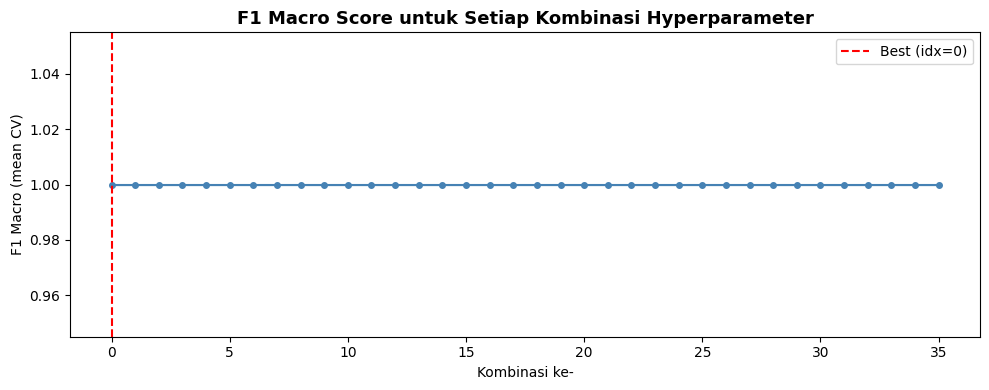

✅ Plot GridSearch disimpan sebagai gridsearch_results.png


In [27]:
# ── Visualisasi hasil tuning (pengaruh n_estimators vs max_depth terhadap F1) ──
cv_results_df = pd.DataFrame(grid_search.cv_results_)

# Plot distribusi skor CV dari semua kombinasi
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(len(cv_results_df)), cv_results_df['mean_test_score'], marker='o', ms=4, color='steelblue')
ax.fill_between(
    range(len(cv_results_df)),
    cv_results_df['mean_test_score'] - cv_results_df['std_test_score'],
    cv_results_df['mean_test_score'] + cv_results_df['std_test_score'],
    alpha=0.2, color='steelblue'
)
best_idx = grid_search.best_index_
ax.axvline(best_idx, color='red', linestyle='--', label=f'Best (idx={best_idx})')
ax.set_title('F1 Macro Score untuk Setiap Kombinasi Hyperparameter', fontsize=13, fontweight='bold')
ax.set_xlabel('Kombinasi ke-')
ax.set_ylabel('F1 Macro (mean CV)')
ax.legend()
plt.tight_layout()
plt.savefig('gridsearch_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot GridSearch disimpan sebagai gridsearch_results.png")

> **Interpretasi:** GridSearchCV mengevaluasi semua kombinasi parameter secara sistematis menggunakan 5-fold CV. Garis merah menandai kombinasi dengan F1 Macro tertinggi yang akan digunakan sebagai model final. Bayangan biru menunjukkan ±1 standar deviasi — kombinasi dengan std kecil lebih stabil.

---
## 🔹 Tahap 8: Evaluasi Akhir (Test Set)

In [28]:
# ── Prediksi pada test set ──
y_pred = best_estimator.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
test_f1       = f1_score(y_test, y_pred, average='macro')

print("=" * 55)
print("EVALUASI AKHIR — TEST SET")
print("=" * 55)
print(f"Accuracy  : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"F1 Macro  : {test_f1:.4f}")

EVALUASI AKHIR — TEST SET
Accuracy  : 1.0000 (100.00%)
F1 Macro  : 1.0000


In [29]:
# ── Laporan Klasifikasi ──
print("\n=" * 55)
print("CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=le.classes_.astype(str)))


=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17730
           1       1.00      1.00      1.00    191985

    accuracy                           1.00    209715
   macro avg       1.00      1.00      1.00    209715
weighted avg       1.00      1.00      1.00    209715



> **Interpretasi:** Classification report menampilkan Precision, Recall, dan F1-score per kelas. Nilai *support* menunjukkan jumlah sampel uji per kelas. *Macro avg* memberikan rata-rata tanpa mempertimbangkan jumlah sampel; *weighted avg* mempertimbangkan proporsi tiap kelas.

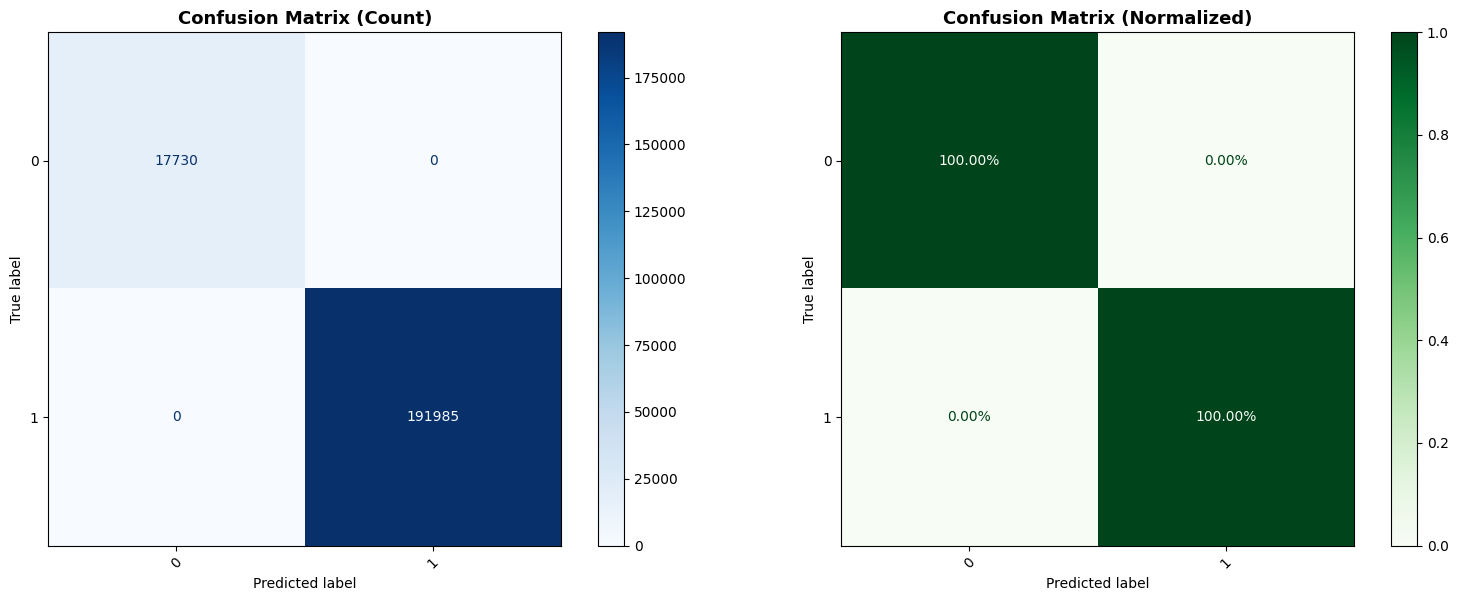

✅ Confusion matrix disimpan sebagai confusion_matrix.png


In [30]:
# ── Confusion Matrix ──
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Confusion Matrix angka
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=axes[0], cmap='Blues', colorbar=True)
axes[0].set_title('Confusion Matrix (Count)', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Confusion Matrix persentase (normalized)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=le.classes_)
disp2.plot(ax=axes[1], cmap='Greens', colorbar=True,
           values_format='.2%')
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix disimpan sebagai confusion_matrix.png")

> **Interpretasi:** Confusion matrix kiri menampilkan jumlah absolut prediksi per kelas; kanan menampilkan persentase row-wise (recall per kelas). Diagonal utama adalah prediksi benar. Sel di luar diagonal menunjukkan misklasifikasi — baris adalah kelas aktual, kolom adalah kelas prediksi.

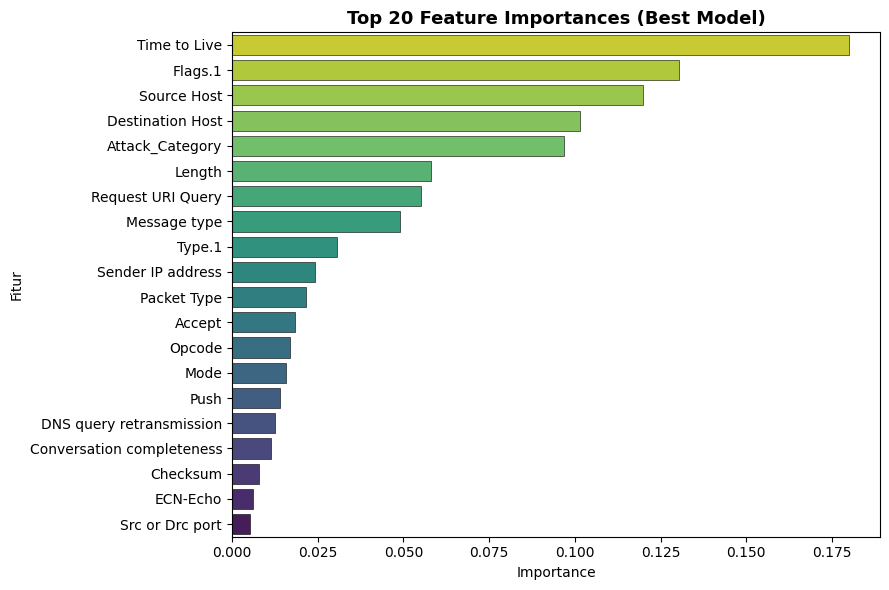

✅ Feature importance disimpan sebagai feature_importance.png


In [31]:
# ── Feature Importance dari best_estimator ──
try:
    # Ambil nama fitur setelah feature selection
    fs_step = best_estimator.named_steps['feature_selection']
    selected_mask = fs_step.get_support()
    selected_features = np.array(X.columns)[selected_mask]

    importances = best_estimator.named_steps['model'].feature_importances_
    feat_imp_df = pd.DataFrame({'Feature': selected_features, 'Importance': importances})
    feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(9, 6))
    sns.barplot(data=feat_imp_df, x='Importance', y='Feature',
                palette='viridis_r', ax=ax, edgecolor='black', linewidth=0.4)
    ax.set_title('Top 20 Feature Importances (Best Model)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance')
    ax.set_ylabel('Fitur')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Feature importance disimpan sebagai feature_importance.png")
except Exception as e:
    print(f"Tidak dapat menampilkan feature importance: {e}")

In [32]:
# ── Simpan Pipeline Terbaik ──
MODEL_PATH = 'pipeline_terbaik.pkl'
joblib.dump(best_estimator, MODEL_PATH)
print(f"✅ Pipeline terbaik berhasil disimpan sebagai '{MODEL_PATH}'")
print(f"   Ukuran file: {os.path.getsize(MODEL_PATH) / 1024:.1f} KB")

# Verifikasi: load kembali dan prediksi satu sampel
loaded_pipeline = joblib.load(MODEL_PATH)
sample_pred = loaded_pipeline.predict(X_test.iloc[:1])
print(f"\nVerifikasi load model — prediksi sampel pertama:")
print(f"  Prediksi (encoded) : {sample_pred[0]}")
print(f"  Prediksi (label)   : {le.inverse_transform(sample_pred)[0]}")
print(f"  Aktual (label)     : {le.inverse_transform([y_test.iloc[0]])[0]}")

✅ Pipeline terbaik berhasil disimpan sebagai 'pipeline_terbaik.pkl'
   Ukuran file: 169.0 KB

Verifikasi load model — prediksi sampel pertama:
  Prediksi (encoded) : 1
  Prediksi (label)   : 1
  Aktual (label)     : 1


In [33]:
# ── Simpan LabelEncoder (diperlukan di app.py) ──
joblib.dump(le, 'label_encoder.pkl')
print("✅ LabelEncoder disimpan sebagai 'label_encoder.pkl'")
print("   (Gunakan file ini di mlflow.py dan app.py)")

✅ LabelEncoder disimpan sebagai 'label_encoder.pkl'
   (Gunakan file ini di mlflow.py dan app.py)


In [34]:
# ── Ringkasan Akhir ──
print("\n" + "#" * 60)
print("# RINGKASAN HASIL BAGIAN A")
print("#" * 60)
print(f"Dataset            : Preprocessed Balanced IoT Vulnerability")
print(f"Jumlah fitur asli  : {X.shape[1]}")
print(f"Jumlah fitur dipilih: {N_FEATURES}")
print(f"Metode FS terbaik  : {method_label[best_method]}")
print(f"Best CV F1 Macro   : {grid_search.best_score_:.4f}")
print(f"Test Accuracy      : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test F1 Macro      : {test_f1:.4f}")
print("\nFile yang dihasilkan:")
for fname in ['pipeline_terbaik.pkl', 'label_encoder.pkl',
              'distribusi_label.png', 'heatmap_korelasi.png',
              'cv_barchart.png', 'cv_boxplot_f1.png',
              'gridsearch_results.png', 'confusion_matrix.png',
              'feature_importance.png']:
    status = "✅" if os.path.exists(fname) else "⚠️  (belum ada)"
    print(f"  {status} {fname}")
print("#" * 60)


############################################################
# RINGKASAN HASIL BAGIAN A
############################################################
Dataset            : Preprocessed Balanced IoT Vulnerability
Jumlah fitur asli  : 87
Jumlah fitur dipilih: 43
Metode FS terbaik  : Filter (SelectKBest)
Best CV F1 Macro   : 1.0000
Test Accuracy      : 1.0000 (100.00%)
Test F1 Macro      : 1.0000

File yang dihasilkan:
  ✅ pipeline_terbaik.pkl
  ✅ label_encoder.pkl
  ✅ distribusi_label.png
  ✅ heatmap_korelasi.png
  ✅ cv_barchart.png
  ✅ cv_boxplot_f1.png
  ✅ gridsearch_results.png
  ✅ confusion_matrix.png
  ✅ feature_importance.png
############################################################
